<a href="https://colab.research.google.com/github/Shiyasalloor/Computer_Vision_Lab/blob/main/Block_Matching_using_SAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

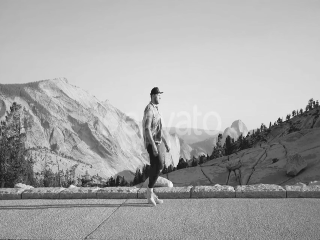

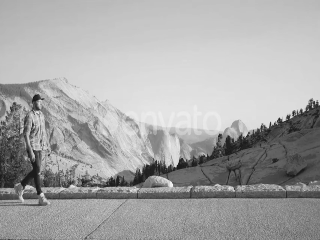

-1

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# ---------- Load Images ----------
img1 = cv2.imread('/content/frame1.png', 0)  # grayscale
img2 = cv2.imread('/content/frame2.png', 0)

img1 = cv2.resize(img1, (320,240))
img2 = cv2.resize(img2, (320,240))

cv2_imshow(img1)
cv2_imshow(img2)
cv2.waitKey(0)

In [9]:
def SAD(block1, block2):
    return np.sum(np.abs(block1 - block2))

In [10]:
def block_matching(img1, img2, block_size=16, search_range=8):
    h, w = img1.shape

    motion_vectors = []

    for y in range(0, h-block_size, block_size):
        for x in range(0, w-block_size, block_size):

            block = img1[y:y+block_size, x:x+block_size]

            best_sad = float('inf')
            best_dx, best_dy = 0, 0

            # Search window
            for dy in range(-search_range, search_range+1):
                for dx in range(-search_range, search_range+1):

                    nx = x + dx
                    ny = y + dy

                    if nx < 0 or ny < 0 or nx+block_size > w or ny+block_size > h:
                        continue

                    candidate = img2[ny:ny+block_size, nx:nx+block_size]
                    sad = SAD(block, candidate)

                    if sad < best_sad:
                        best_sad = sad
                        best_dx, best_dy = dx, dy

            motion_vectors.append((x, y, best_dx, best_dy))

    return motion_vectors

In [11]:
vectors = block_matching(img1, img2, block_size=16, search_range=8)
print("Total motion vectors:", len(vectors))

Total motion vectors: 266


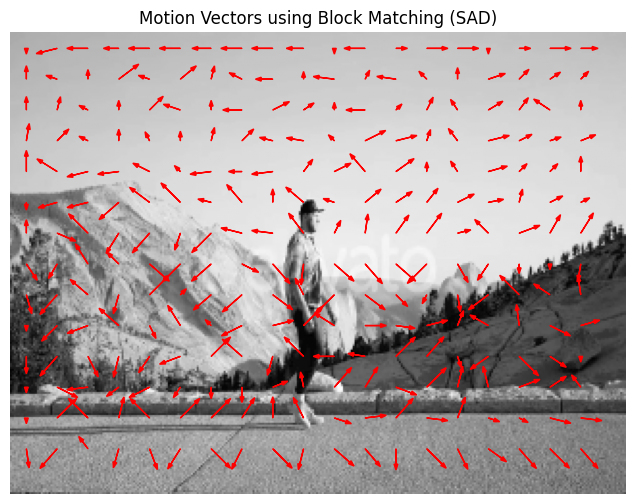

In [12]:
plt.figure(figsize=(8,6))
plt.imshow(img1, cmap='gray')

for (x, y, dx, dy) in vectors:
    plt.arrow(x+8, y+8, dx, dy, color='red', head_width=2)

plt.title("Motion Vectors using Block Matching (SAD)")
plt.axis('off')
plt.show()

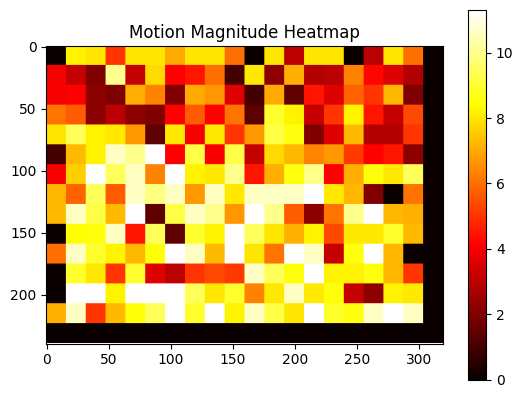

In [13]:
motion_mag = np.zeros_like(img1, dtype=float)

for (x, y, dx, dy) in vectors:
    mag = np.sqrt(dx**2 + dy**2)
    motion_mag[y:y+16, x:x+16] = mag

plt.imshow(motion_mag, cmap='hot')
plt.colorbar()
plt.title("Motion Magnitude Heatmap")
plt.show()